In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

import warnings
warnings.filterwarnings("ignore")

In [33]:
df = pd.read_csv("salaries.csv")
df= df.drop(columns=[
    "Unnamed: 0",
    "salary",
    "salary_currency"
])
df.rename(columns={"salary_in_usd":"Salary(USD)"}, inplace=True)

experience_mapping = {
    "EN": 1,
    "MI": 4,
    "SE": 7,
    "EX": 12
}
df["experience_years"] = df["experience_level"].map(experience_mapping)

def remote_type(value):
    if value == 0:
        return "On-site"
    elif value == 50:
        return "Hybrid"
    else:
        return "Remote"

df["remote_type"] = df["remote_ratio"].apply(remote_type)

region_mapping = {
    "US": "North America",
    "CA": "North America",

    "IN": "Asia",
    "JP": "Asia",
    "SG": "Asia",
    "CN": "Asia",

    "GB": "Europe",
    "DE": "Europe",
    "FR": "Europe",
    "ES": "Europe",
    "NL": "Europe"
}
df["company_region"] = (
    df["company_location"]
      .map(region_mapping)
      .fillna("Other")
)

df["work_year"] = df["work_year"] + 3

df.info()
df.describe()
df.shape
df.columns
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           607 non-null    int64 
 1   experience_level    607 non-null    object
 2   employment_type     607 non-null    object
 3   job_title           607 non-null    object
 4   Salary(USD)         607 non-null    int64 
 5   employee_residence  607 non-null    object
 6   remote_ratio        607 non-null    int64 
 7   company_location    607 non-null    object
 8   company_size        607 non-null    object
 9   experience_years    607 non-null    int64 
 10  remote_type         607 non-null    object
 11  company_region      607 non-null    object
dtypes: int64(4), object(8)
memory usage: 57.0+ KB
None


,work_year,experience_level,employment_type,job_title,Salary(USD),employee_residence,remote_ratio,company_location,company_size,experience_years,remote_type,company_region
0,2023,MI,FT,Data Scientist,79833,DE,0,DE,L,4,On-site,Europe
1,2023,SE,FT,Machine Learning Scientist,260000,JP,0,JP,S,7,On-site,Asia
2,2023,SE,FT,Big Data Engineer,109024,GB,50,GB,M,7,Hybrid,Europe
3,2023,MI,FT,Product Data Analyst,20000,HN,0,HN,S,4,On-site,Other
4,2023,SE,FT,Machine Learning Engineer,150000,US,50,US,L,7,Hybrid,North America


In [8]:
df.isnull().sum()
df.duplicated().sum()

np.int64(0)

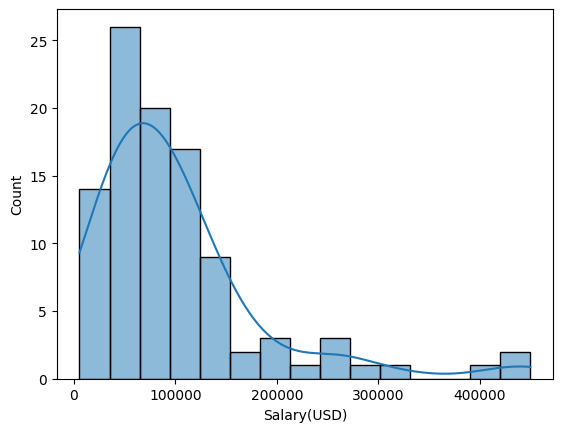

In [9]:
sns.histplot(df["Salary(USD)"], kde=True)
plt.show()

<Axes: xlabel='experience_years', ylabel='Salary(USD)'>

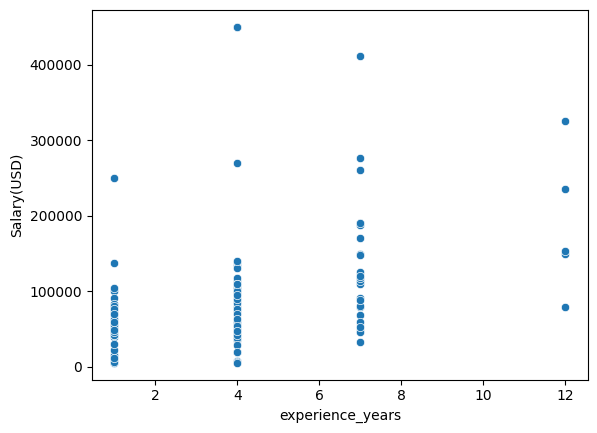

In [10]:
sns.scatterplot(
    x="experience_years",
    y="Salary(USD)",
    data=df
)

<Axes: xlabel='count', ylabel='job_title'>

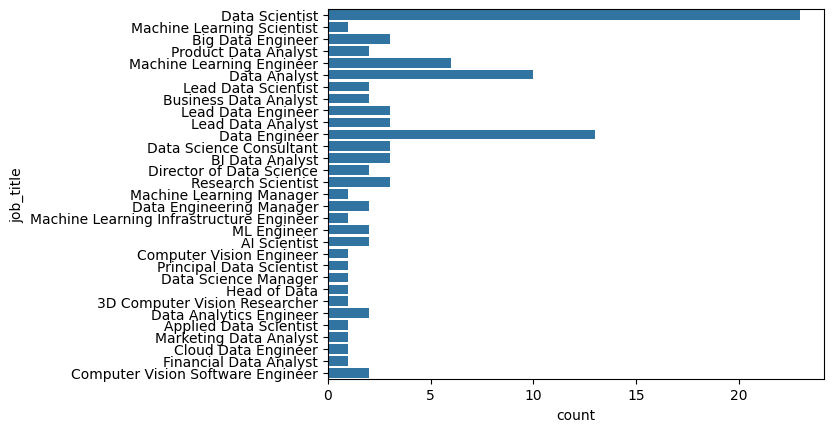

In [11]:
sns.countplot(
    y="job_title",
    data=df
)

<Axes: >

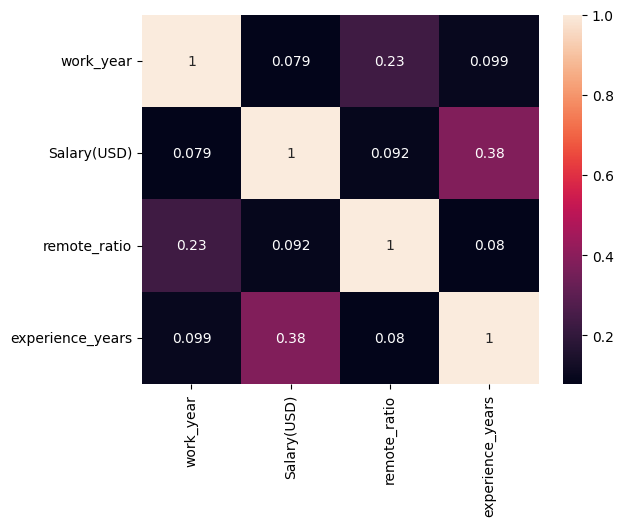

In [12]:
sns.heatmap(df.corr(numeric_only=True),
            annot=True)

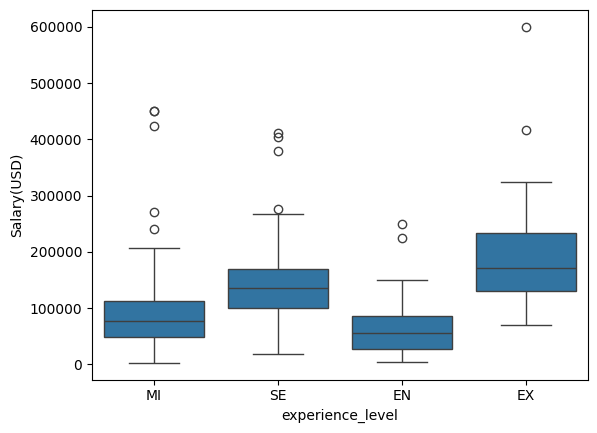

In [34]:
sns.boxplot(
    x="experience_level",
    y="Salary(USD)",
    data=df
)
plt.xticks(rotation=0)
plt.show()

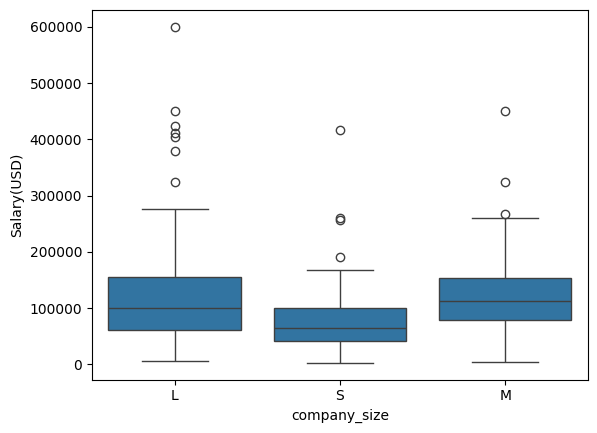

In [35]:
sns.boxplot(
    x="company_size",
    y="Salary(USD)",
    data=df
)
plt.show()

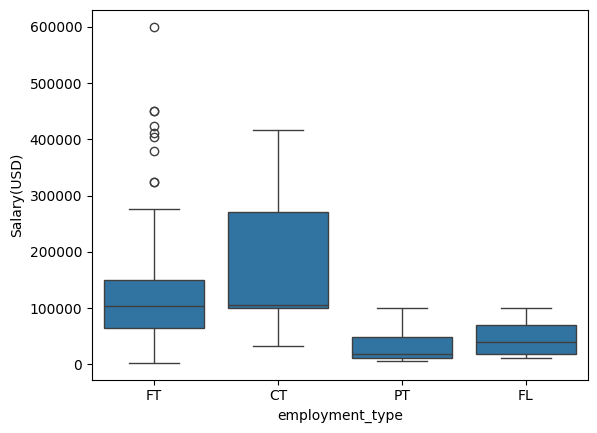

In [36]:
sns.boxplot(
    x="employment_type",
    y="Salary(USD)",
    data=df
)
plt.show()

In [13]:
X=df.drop("Salary(USD)",axis=1)
Y=df["Salary(USD)"]

In [14]:
print(X.dtypes)

work_year              int64
experience_level      object
employment_type       object
job_title             object
employee_residence    object
remote_ratio           int64
company_location      object
company_size          object
experience_years       int64
remote_type           object
company_region        object
dtype: object


In [15]:
categorical_cols = X.select_dtypes(include=['object']).columns

numerical_cols = X.select_dtypes(exclude=['object']).columns

print("Categorical Columns:")
print(categorical_cols)

print("\nNumerical Columns:")
print(numerical_cols)

Categorical Columns:
Index(['experience_level', 'employment_type', 'job_title',
       'employee_residence', 'company_location', 'company_size', 'remote_type',
       'company_region'],
      dtype='object')

Numerical Columns:
Index(['work_year', 'remote_ratio', 'experience_years'], dtype='object')


In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_cols
        )
    ],
    remainder="passthrough"
)

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

# Building Model

# 1) Linear Regression

In [18]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

lr_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

lr_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['experience_level', 'employment_type', 'job_title',
       'employee_residence', 'company_location', 'company_size', 'remote_type',
       'company_region'],
      dtype='object'))])),
                ('model', LinearRegression())])

In [19]:
lr_pred = lr_model.predict(X_test)

In [20]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

print("Linear Regression")

print("MAE :", mean_absolute_error(y_test, lr_pred))

print("RMSE :", np.sqrt(mean_squared_error(y_test, lr_pred)))

print("R² :", r2_score(y_test, lr_pred))

Linear Regression
MAE : 101282.90556030274
RMSE : 141386.7764496819
R² : -1.3432694979048558


## 2) Decision Tree Regressor

In [21]:
from sklearn.tree import DecisionTreeRegressor

dt_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeRegressor(
        random_state=42
    ))
])

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

In [22]:
print("Decision Tree")

print("MAE :", mean_absolute_error(y_test, dt_pred))

print("RMSE :", np.sqrt(mean_squared_error(y_test, dt_pred)))

print("R² :", r2_score(y_test, dt_pred))

Decision Tree
MAE : 39566.5
RMSE : 80382.80601658541
R² : 0.24259009775388496


# 3) Random Forest

In [23]:
from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        RandomForestRegressor(
            n_estimators=300,
            random_state=42
        )
    )
])

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [24]:
print("Random Forest")

print("MAE :", mean_absolute_error(y_test, rf_pred))

print("RMSE :", np.sqrt(mean_squared_error(y_test, rf_pred)))

print("R² :", r2_score(y_test, rf_pred))

Random Forest
MAE : 37162.55311111111
RMSE : 77077.53109421153
R² : 0.30359762451472594


# 4) XGBoost

In [25]:
from xgboost import XGBRegressor

In [26]:
xgb_model = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        XGBRegressor(
            random_state=42,
            n_estimators=300
        )
    )
])

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

In [27]:
print("XGBoost")

print("MAE :", mean_absolute_error(y_test, xgb_pred))

print("RMSE :", np.sqrt(mean_squared_error(y_test, xgb_pred)))

print("R² :", r2_score(y_test, xgb_pred))

XGBoost
MAE : 43912.49609375
RMSE : 84975.78158510813
R² : 0.15356230735778809


# **Comparing All Models**

In [28]:
results = {
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "MAE": [
        mean_absolute_error(y_test, lr_pred),
        mean_absolute_error(y_test, dt_pred),
        mean_absolute_error(y_test, rf_pred),
        mean_absolute_error(y_test, xgb_pred)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, lr_pred)),
        np.sqrt(mean_squared_error(y_test, dt_pred)),
        np.sqrt(mean_squared_error(y_test, rf_pred)),
        np.sqrt(mean_squared_error(y_test, xgb_pred))
    ],
    "R² Score": [
        r2_score(y_test, lr_pred),
        r2_score(y_test, dt_pred),
        r2_score(y_test, rf_pred),
        r2_score(y_test, xgb_pred)
    ]
}

comparison = pd.DataFrame(results)

comparison.sort_values(
    by="R² Score",
    ascending=False
)

,Model,MAE,RMSE,R² Score
2,Random Forest,37162.553111,77077.531094,0.303598
1,Decision Tree,39566.500000,80382.806017,0.242590
3,XGBoost,43912.496094,84975.781585,0.153562
0,Linear Regression,101282.905560,141386.776450,-1.343269


# **Saving the Best Model**

In [29]:
import joblib

joblib.dump(rf_model, "employee_salary_prediction.pkl")

['employee_salary_prediction.pkl']

# Testing

In [30]:
new_employee = pd.DataFrame({
    "work_year": [2026],
    "experience_level": ["SE"],
    "employment_type": ["FT"],
    "job_title": ["Machine Learning Engineer"],
    "remote_ratio": [50],
    "company_location": ["US"],
    "employee_residence":["US"],
    "company_size": ["L"],
    "experience_years": [7],
    "remote_type": ["Hybrid"],
    "company_region": ["North America"],
    "company_size_score": [3]
})

prediction = rf_model.predict(new_employee)

print(f"Predicted Salary (USD): ${prediction[0]:,.2f}")

Predicted Salary (USD): $185,430.67
